### 1. Import necessary libraries

In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

### 2. Load the saved model

In [11]:
model = tf.keras.models.load_model("trained_model.keras")
print("✅ Model loaded successfully.")



✅ Model loaded successfully.


### 3. Load the test/validation dataset

In [12]:

test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',  # adjust folder path if needed
    labels="inferred",
    label_mode="categorical",
    image_size=(128, 128),
    shuffle=False
)

Found 5198 files belonging to 11 classes.


###  4. Predict using the loaded model

In [13]:
y_pred = model.predict(test_set)
y_pred_classes = tf.argmax(y_pred, axis=1).numpy()

163/163 [==============================] - 3s 20ms/step


### 5. Get true labels


In [14]:
y_true = []
for images, labels in test_set:
    y_true.extend(tf.argmax(labels, axis=1).numpy())
y_true = np.array(y_true)


### 6. Confusion Matrix


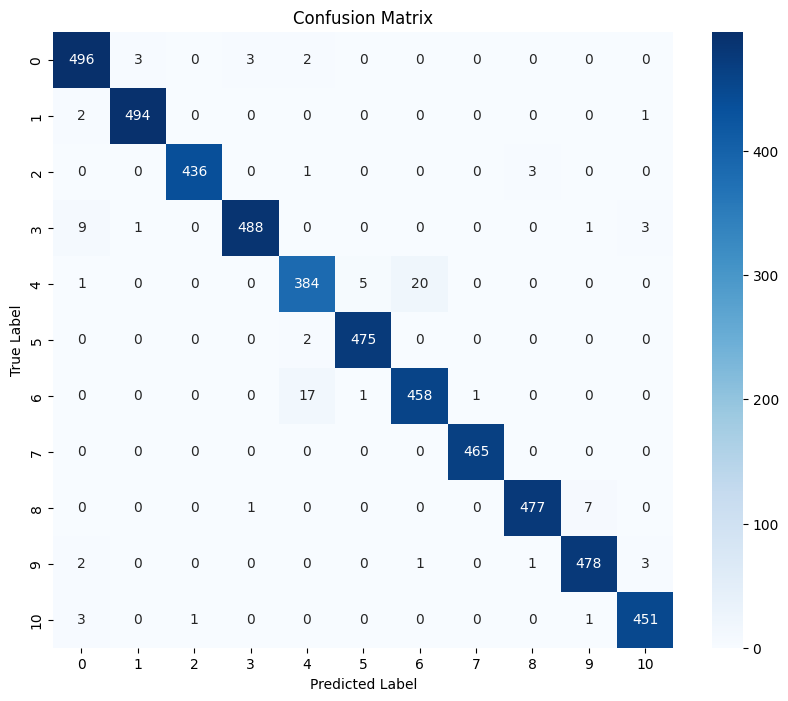

In [15]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### 7. Classification Report

In [16]:
class_names = test_set.class_names
print("\n📋 Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))


📋 Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.98      0.98       504
                                 Apple___Black_rot       0.99      0.99      0.99       497
                          Apple___Cedar_apple_rust       1.00      0.99      0.99       440
                                   Apple___healthy       0.99      0.97      0.98       502
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.95      0.94      0.94       410
                       Corn_(maize)___Common_rust_       0.99      1.00      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.96      0.96      0.96       477
                            Corn_(maize)___healthy       1.00      1.00      1.00       465
                             Potato___Early_blight       0.99      0.98      0.99       485
                              Potato___Late_blight  

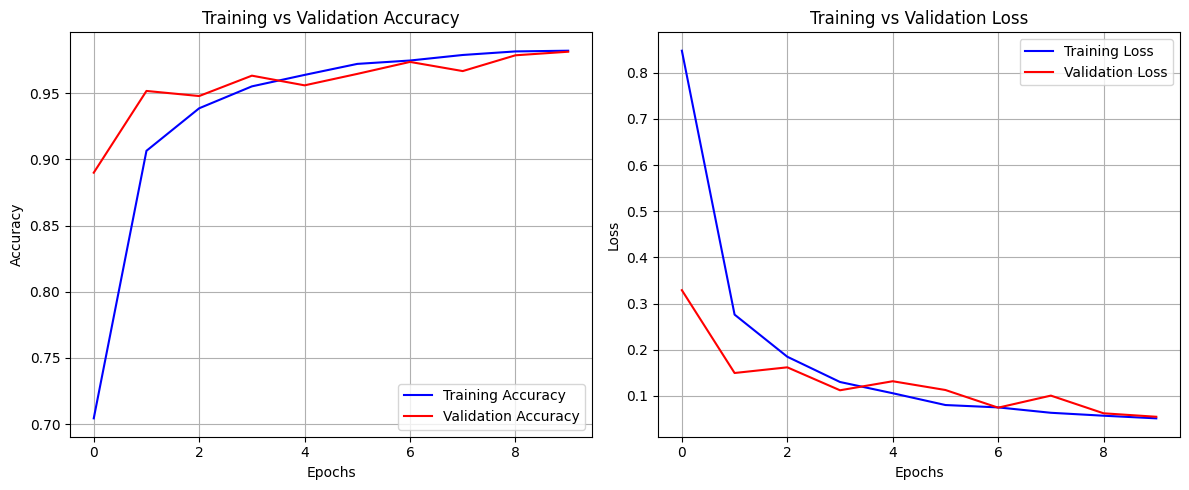

In [17]:
# Load training history from JSON file
import json

with open('training_hist.json', 'r') as f:
    history_dict = json.load(f)

# Create a mock history object for plotting
class History:
    def __init__(self, history_dict):
        self.history = history_dict

history = History(history_dict)

# Create accuracy and loss plots
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], 'b-', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], 'r-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], 'b-', label='Training Loss')
plt.plot(history.history['val_loss'], 'r-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()